In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


***Étape 1 : Chargement des données***

In [135]:
# Importation des ensembles d'entraînement et de test
df_train = pd.read_csv("airbnb_train.csv")
df_test = pd.read_csv("airbnb_test.csv")

# Standardisation du nom de la colonne identifiant
df_test.columns = ['id' if col == 'Unnamed: 0' else col for col in df_test.columns]


Chargement des fichiers CSV contenant les données.

airbnb_train.csv contient les logements avec leur log_price (à apprendre).

airbnb_test.csv contient les logements sans log_price (à prédire).

La colonne "Unnamed: 0" (crée automatiquement par pandas lors d'une sauvegarde avec index) est renommée en "id".

**Étape 2 : Exploration des données**

In [136]:
# Visualiser les cinq premières lignes
train_df.iloc[:5]

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0
3,17954362,3.555348,House,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,Real Bed,flexible,True,...,2017-09-29,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0
4,9969781,5.480639,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,moderate,True,...,2017-08-28,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0


In [137]:
#Afficher les 5 derniéres lignes
train_df.tail()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
22229,11989532,4.605170,Apartment,Private room,{},1,1.0,Real Bed,flexible,False,...,NaN,40.709025,-73.939405,one room bushwick,Williamsburg,0,NaN,11206.0,1.0,1.0
22230,20652462,5.043425,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,2.0,Real Bed,moderate,True,...,2017-04-15,33.871549,-118.396053,Spacious Hermosa 2 BR on PCH,Hermosa Beach,16,93.0,90254,2.0,4.0
22231,12380210,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5,1.0,Real Bed,moderate,True,...,2017-09-10,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,Williamsburg,43,94.0,11206.0,2.0,2.0
22232,19533966,5.273000,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.0,Real Bed,strict,True,...,NaN,40.738535,-74.000157,Designer's Apartment in HEART of NYC,West Village,0,NaN,10011,0.0,2.0
22233,18507240,4.852030,Boat,Entire home/apt,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",4,1.0,Real Bed,moderate,False,...,2017-04-30,33.761096,-118.192409,Cozy Boat at Shoreline Village,Long Beach,205,96.0,90802,1.0,2.0


In [138]:
#Afficher le nombre d'individus et le nombre de caractéristiques étudiées
print("Shape:", train_df.shape)

Shape: (22234, 28)


In [139]:
#Afficher les caractéristiques etudiés
train_df.columns

Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')

In [140]:
# Fonction pour afficher les informations du DataFrame
def afficher_info(df):
    print("\nRésumé des données :")
    df.info()

afficher_info(train_df)


Résumé des données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22234 entries, 0 to 22233
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      22234 non-null  int64  
 1   log_price               22234 non-null  float64
 2   property_type           22234 non-null  object 
 3   room_type               22234 non-null  object 
 4   amenities               22234 non-null  object 
 5   accommodates            22234 non-null  int64  
 6   bathrooms               22183 non-null  float64
 7   bed_type                22234 non-null  object 
 8   cancellation_policy     22234 non-null  object 
 9   cleaning_fee            22234 non-null  bool   
 10  city                    22234 non-null  object 
 11  description             22234 non-null  object 
 12  first_review            17509 non-null  object 
 13  host_has_profile_pic    22178 non-null  object 
 14  host_identity_ve

In [141]:
# Résumé statistique des variables numériques
print("\nRésumé statistique :")
train_df.describe()


Résumé statistique :


,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,2.223400e+04,22234.000000,22234.000000,22183.000000,22234.000000,22234.000000,22234.000000,17256.000000,22208.000000,22199.000000
mean,1.122269e+07,4.783481,3.155573,1.236037,38.462971,-92.269305,20.670774,94.069077,1.264769,1.711473
std,6.080480e+06,0.718758,2.143870,0.586246,3.071679,21.670081,37.183731,7.782235,0.852819,1.254903
min,3.362000e+03,2.302585,1.000000,0.000000,33.339002,-122.510940,0.000000,20.000000,0.000000,0.000000
25%,6.202924e+06,4.317488,2.000000,1.000000,34.136082,-118.340633,1.000000,92.000000,1.000000,1.000000
50%,1.217425e+07,4.700480,2.000000,1.000000,40.662632,-76.994944,6.000000,96.000000,1.000000,1.000000
75%,1.639502e+07,5.220356,4.000000,1.000000,40.746358,-73.954599,23.000000,100.000000,1.000000,2.000000
max,2.120450e+07,7.600402,16.000000,8.000000,42.390248,-70.989359,505.000000,100.000000,10.000000,18.000000


In [142]:
# Fonction pour afficher les colonnes avec valeurs manquantes
def afficher_manquantes(df):
    pourcentages = df.isnull().mean() * 100
    print("\nColonnes avec données manquantes (en %):")
    return pourcentages[pourcentages > 0].sort_values(ascending=False)

afficher_manquantes(train_df)


Colonnes avec données manquantes (en %):


,0
host_response_rate,24.624449
review_scores_rating,22.389134
first_review,21.251237
last_review,21.210758
neighbourhood,9.382028
zipcode,1.362778
host_has_profile_pic,0.251867
host_identity_verified,0.251867
host_since,0.251867
bathrooms,0.229378


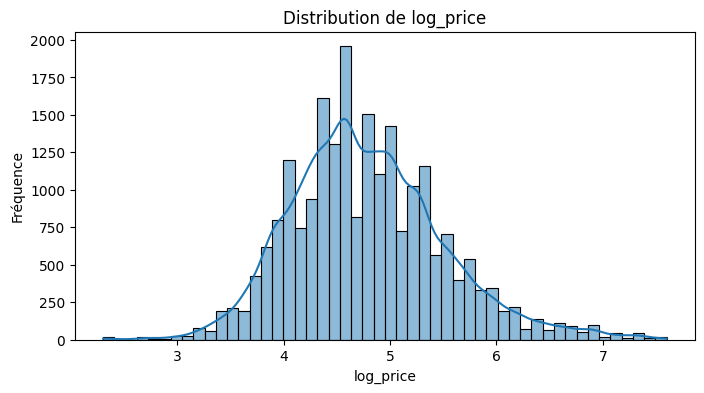

In [143]:
# Fonction pour tracer la distribution de la variable cible
def tracer_distribution(df, colonne):
    plt.figure(figsize=(8, 4))
    sns.histplot(df[colonne], bins=50, kde=True)
    plt.title(f"Distribution de {colonne}")
    plt.xlabel(colonne)
    plt.ylabel("Fréquence")
    plt.show()

tracer_distribution(train_df, "log_price")

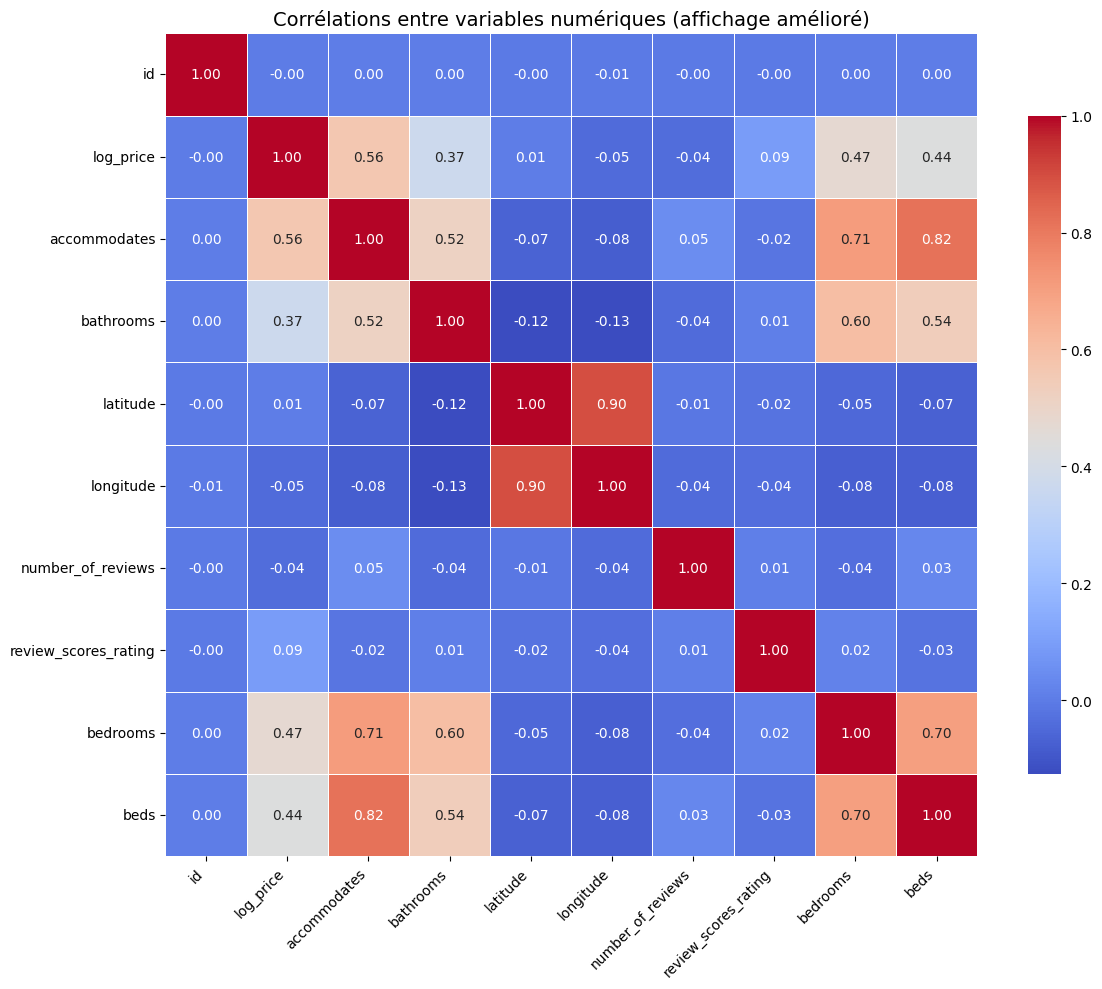

In [144]:
# Corrélation entre variables numériques
numeric_features = train_df.select_dtypes(include=["float64", "int64"])
correlation_matrix = numeric_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5,        # Lignes entre les cases
            linecolor='white',     # Couleur des lignes
            cbar_kws={'shrink': 0.8})  # Réduction de la barre de couleur
plt.title("Corrélations entre variables numériques (affichage amélioré)", fontsize=14)
plt.xticks(rotation=45, ha='right')  # Orientation lisible des labels
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

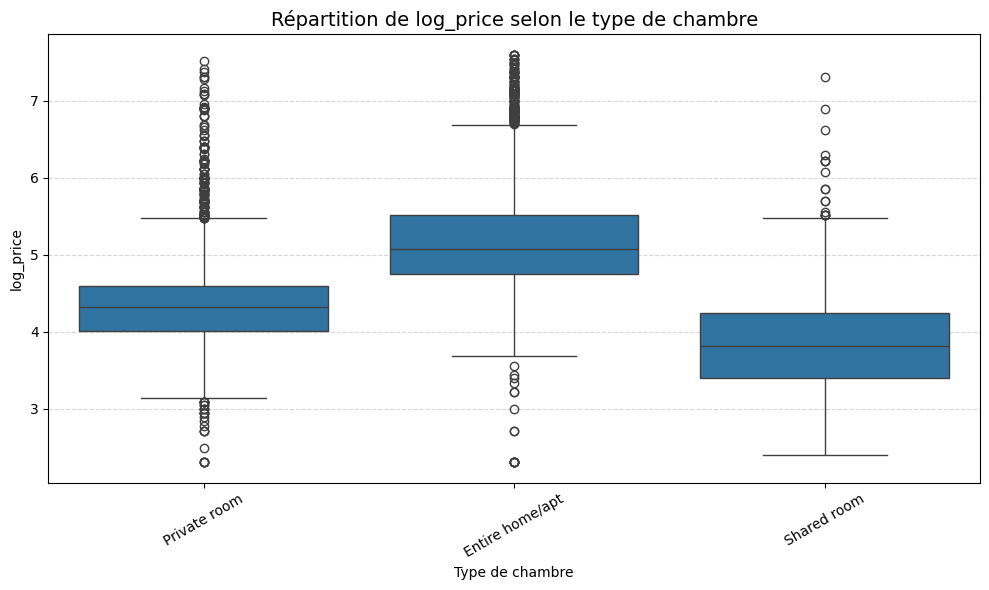

In [145]:
# Visualisation des prix en fonction du type de chambre (log_price)
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x="room_type", y="log_price")
plt.title("Répartition de log_price selon le type de chambre", fontsize=14)
plt.xlabel("Type de chambre")
plt.ylabel("log_price")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

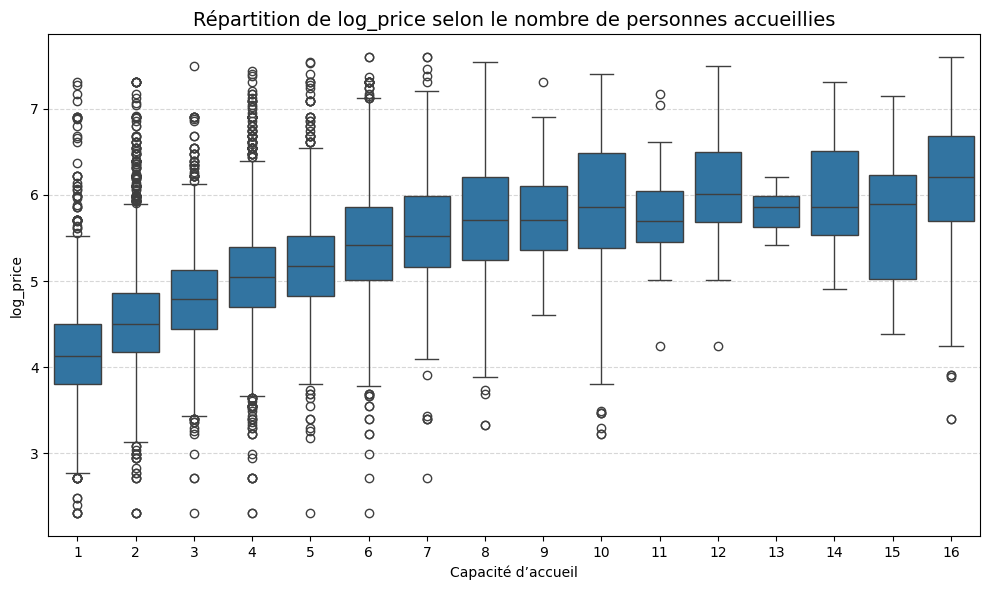

In [146]:
# Analyse du prix en fonction de la capacité d'accueil
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x="accommodates", y="log_price")
plt.title("Répartition de log_price selon le nombre de personnes accueillies", fontsize=14)
plt.xlabel("Capacité d’accueil")
plt.ylabel("log_price")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

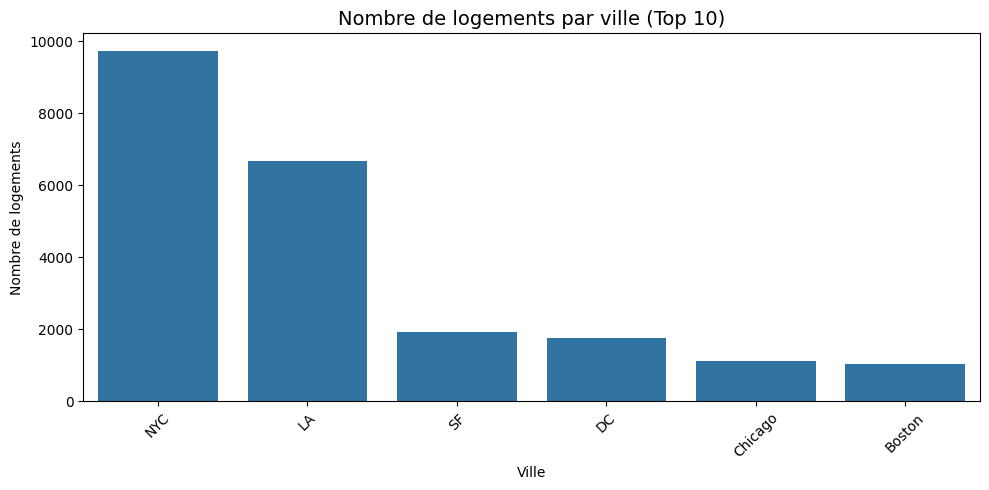

In [147]:
# Top 10 des villes avec le plus de logements
top_villes = train_df["city"].value_counts().nlargest(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_villes.index, y=top_villes.values)
plt.title("Nombre de logements par ville (Top 10)", fontsize=14)
plt.xlabel("Ville")
plt.ylabel("Nombre de logements")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

***Étape 3 : Séparation de la cible (log_price)***

In [148]:
y = train_df["log_price"]
X = train_df.drop(columns=["log_price", "id"])
X_test = test_df.drop(columns=["id"])

Séparation les features (X) de la variable à prédire (y).

y = variable cible, c'est le logarithme du prix à prédire.

X = données d’entrée (features).

X_test = les caractéristiques du jeu de test sur lesquelles on fera la prédiction.

***Étape 4 : Sélection des colonnes pertinentes***

In [149]:
# Colonnes textuelles catégorielles (à encoder)
text_cols = ["property_type", "room_type", "bed_type", "cancellation_policy", "city"]

# Colonnes booléennes
bool_cols = ["cleaning_fee", "host_has_profile_pic", "host_identity_verified", "instant_bookable"]

# Colonnes numériques
numeric_cols = ["accommodates", "bathrooms", "number_of_reviews", "review_scores_rating", "bedrooms", "beds"]

# Colonnes à exclure (trop complexes ou non numériques pour ce modèle simple)
drop_cols = ["name", "description", "first_review", "host_since", "last_review", "zipcode",
             "amenities", "host_response_rate", "latitude", "longitude", "neighbourhood"]

Regroupement les colonnes par type (numérique, catégorielle, booléenne).

On met de côté les colonnes qu’on ne va pas utiliser dans cette première version du modèle, car elles demandent un traitement plus avancé.

***Étape 5: Nettoyage initial***

In [150]:
# Nettoyage initial : on enlève les colonnes inutilisées
X = X.drop(columns=drop_cols, errors='ignore')
X_test = X_test.drop(columns=drop_cols, errors='ignore')

Suppression de X et X_test les colonnes non utilisées.
L’option errors='ignore' évite une erreur si une colonne est absente.

***Étape 6 :Prétraitement des données avec ColumnTransformer***

In [151]:
preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), text_cols),
    ("bool", "passthrough", bool_cols)  # Les booléens sont déjà utilisables
])

**SimpleImputer** : Remplacement les valeurs manquantes dans les colonnes numériques par la médiane.

**OneHotEncoder** : Conversion les catégories textuelles en colonnes numériques binaires.

Les colonnes booléennes sont conservées telles quelles.

***Étape 7 : Construction du modèle avec pipeline***

In [152]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6))
])

Le pipeline combine le prétraitement et le modèle XGBoost.

**XGBRegressor** est un puissant algorithme de boosting très performant pour ce type de tâche.

In [153]:
# Séparation des données en apprentissage et validation (80/20)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

***Étape 8 : Entraînement du modèle***

In [162]:
# Transformation des colonnes contenant des booléens encodés en chaînes
colonnes_bool = ["cleaning_fee", "host_has_profile_pic", "host_identity_verified", "instant_bookable"]

def appliquer_conversion_booleenne(df):
    for colonne in colonnes_bool:
        if colonne in df.columns:
            df[colonne] = df[colonne].map({'t': True, 'f': False})
    return df

# Application de la conversion sur les deux ensembles
X = appliquer_conversion_booleenne(X)
X_test = appliquer_conversion_booleenne(X_test)

Conversion des colonnes contenant des chaînes 't' / 'f' en True / False  (booléens) .

Entraînement du modèle en utilisant les logements du dataset train_df pour apprendre à prédire le log_price.

In [163]:
# Encodage booléen : conversion des chaînes 't'/'f' en valeurs True/False
colonnes_a_encoder = ["cleaning_fee", "host_has_profile_pic", "host_identity_verified", "instant_bookable"]

def encoder_booleens(df):
    correspondance = {'t': True, 'f': False}
    for champ in colonnes_a_encoder:
        if champ in df.columns:
            df[champ] = df[champ].map(correspondance)
    return df

# Traitement appliqué aux deux jeux de données
X = encoder_booleens(X)
X_test = encoder_booleens(X_test)

In [160]:
model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['accommodates', 'bathrooms',
                                                   'number_of_reviews',
                                                   'review_scores_rating',
                                                   'bedrooms', 'beds']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['property_type', 'room_type',
                                                   'bed_type',
                                                   'cancellation_policy',
                                                   'city']),
                                                 ('bool', 'passthrough',
                                                  ['cleaning_fee',...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

In [164]:
# Évaluation du modèle : R², MAE, et RMSE sur les données de validation
y_pred = model.predict(X_val)
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f" R² : {r2:.4f}")
print(f" MAE : {mae:.4f}")
print(f" RMSE : {rmse:.4f}")

 R² : 0.6552
 MAE : 0.3171
 RMSE : 0.4203


***Étape 9 : Prédiction sur le jeu de test***

In [165]:
log_preds = model.predict(X_test)

Génèration des prédictions (logarithme du prix) sur les logements du fichier airbnb_test.csv.

***Étape 10 : Création du fichier de soumission***

In [167]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "log_price": log_preds
})
submission.to_csv("submission.csv", index=False)